In [1]:
import os

os.environ["ACCELERATE_TORCH_DEVICE"] = "cpu"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0.0" 

In [2]:
from transformers import pipeline

In [3]:
classificador_sentimento = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [4]:
classificador_sentimento('I love this product!')

[{'label': 'POSITIVE', 'score': 0.9998855590820312}]

In [5]:
classificador_sentimento('I am tottaly disappointed with this product! It is not worth the money I spent on it.')

[{'label': 'NEGATIVE', 'score': 0.9998266100883484}]

## Selecionando um modelo para analise de sentimento em PT

In [6]:
%pip install pysentimiento 

/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/bin/python: No module named pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [7]:
from pysentimiento import create_analyzer

In [8]:
modelo_analise_sentimento = create_analyzer(task="sentiment", lang="pt", device="cpu")

In [9]:
modelo_analise_sentimento.predict('''
A fritadeira é sensacional, muito além do que eu imaginava. É linda, super funcional e muito fácil de manusear.
Fácil de limpar e potente. Super recomendo!
''')

AnalyzerOutput(output=POS, probas={POS: 0.989, NEU: 0.009, NEG: 0.002})

In [10]:
modelo_analise_sentimento.predict('''
Após pouco meses de uso a carcaça de aço escovado começou a oxidar, demonstrando a baixa qualidade de proteção.
Fora esse detalhe, o produto cumpre o prometido. 
''')

AnalyzerOutput(output=NEU, probas={NEU: 0.901, NEG: 0.086, POS: 0.013})

In [11]:
modelo_analise_sentimento.predict('''
Em menos de 1 ano parou de funcionar, enviei para assistência técnica por estar na garantia,
trocaram o motor, passou a ficar menos potente e não durou 2 utilizações.
Isso se repetiu várias vezes, até que desisti de ficar levando lá e queimando de novo em seguida,
vi outros clientes com o mesmo problema. Não comprem!
''')

AnalyzerOutput(output=NEG, probas={NEG: 0.911, NEU: 0.072, POS: 0.017})

## Aplicando o modelo aos Dados

In [12]:
import pandas as pd

In [13]:
dados = pd.read_csv('dados/resenhas.csv')

In [14]:
dados[:5]

,ID,Resenha
0,24,"A fritadeira é sensacional, muito além do que ..."
1,733,"Após usar o produto, achei-o fácil e muito efi..."
2,865,"Muito funcional, prática e moderna."
3,809,"Boa, mas não das melhores pois a frente de vid..."
4,628,Eu comecei a usar e é bem espaçosa. Gostei poi...


In [15]:
# import os

# os.environ["ACCELERATE_TORCH_DEVICE"] = "cpu"
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
# os.environ["CUDA_VISIBLE_DEVICES"] = "0.0" 

In [16]:
resultados_previsao = modelo_analise_sentimento.predict(dados['Resenha'])

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [17]:
resultados_previsao[:5]

[AnalyzerOutput(output=POS, probas={POS: 0.989, NEU: 0.009, NEG: 0.002}),
 AnalyzerOutput(output=POS, probas={POS: 0.670, NEU: 0.320, NEG: 0.011}),
 AnalyzerOutput(output=POS, probas={POS: 0.900, NEU: 0.097, NEG: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.731, NEU: 0.259, POS: 0.010}),
 AnalyzerOutput(output=POS, probas={POS: 0.976, NEU: 0.021, NEG: 0.003})]

In [18]:
sentimento = []

for resultado in resultados_previsao:
    sentimento.append(resultado.output)

In [19]:
sentimento[:5]

['POS', 'POS', 'POS', 'NEG', 'POS']

In [20]:
dados["Sentimento"] = sentimento

In [21]:
dados[:5]

,ID,Resenha,Sentimento
0,24,"A fritadeira é sensacional, muito além do que ...",POS
1,733,"Após usar o produto, achei-o fácil e muito efi...",POS
2,865,"Muito funcional, prática e moderna.",POS
3,809,"Boa, mas não das melhores pois a frente de vid...",NEG
4,628,Eu comecei a usar e é bem espaçosa. Gostei poi...,POS


## Realizando uma analise detalhada dos sentimentos

In [22]:
import plotly.express as px

In [23]:
df_sentimento = dados.groupby('Sentimento').size().reset_index(name='Contagem')

fig = px.bar(df_sentimento, x='Sentimento', y='Contagem', color='Sentimento', title='Contagem de Resenhas por Sentimento')

fig.show()

In [24]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
portuguese_stopwords = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/devbodegami/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [26]:
portuguese_stopwords

{'a',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'estamos',
 'estar',
 'estas',
 'estava',
 'estavam',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéramos',
 'estivéssemos',
 'estou',
 'está',
 'estávamos',
 'estão',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fui',
 'fôramos',
 'fôssemos',
 'haja',
 'hajam',
 'hajamos',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houveram',
 'houverei',
 'houverem',
 'houveremos',
 'houveria',
 'houveriam',
 'houvermos',
 'houverá',
 'houverão',
 'houverí

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def nuvem_palavras(texto, coluna_texto, sentimento):
    # Filtrando as resenhas com base no sentimento especificado
    texto_sentimento = texto.query(f"Sentimento == '{sentimento}'")[coluna_texto]

    # Unindo todas as resenhas em uma única string
    texto_unido = " ".join(texto_sentimento)

    # Dividindo o texto em palavras e filtrando com stopwords
    palavras = texto_unido.split()
    palavras_filtradas = [palavra for palavra in palavras if palavra not in portuguese_stopwords]
    texto_filtrado = " ".join(palavras_filtradas)

    # Criando e exibindo a nuvem de palavras
    nuvem_palavras = WordCloud(width=800, height=500, max_words=50).generate(texto_filtrado)
    plt.figure(figsize=(10, 7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis('off')
    plt.show()

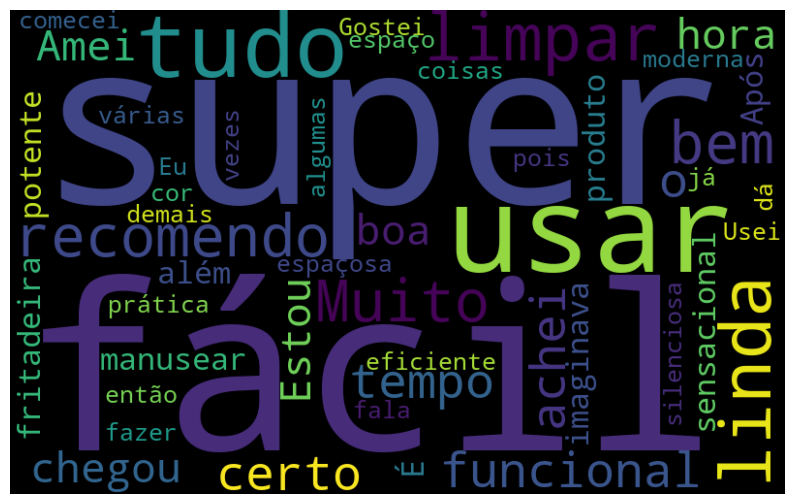

In [29]:
nuvem_palavras(dados, 'Resenha', 'POS')

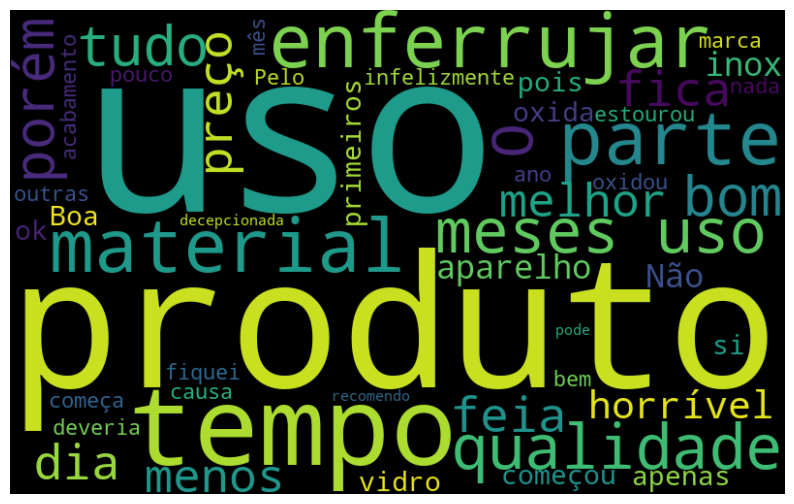

In [30]:
nuvem_palavras(dados, 'Resenha', 'NEG')